# Фінальна оцінка на test

Модель вибрана за validation: baseline_aug (SmallCNN + SpecAugment, 25 епох) - найкращий window F1, вища track accuracy, мінімальний розрив train/val серед усіх прогонів (деталі порівняння в resnet_results.ipynb).

Test (1794 треки) до цього моменту не використовувався ніде - ні для тренування, ні для вибору моделі чи гіперпараметрів. Оцінюємо один раз, ці цифри йдуть у звіт.

In [1]:
import sys
sys.path.append('../src')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix

from dataset import SpectrogramWindows
from models import build_model

CKPT = Path('../../data/runs/baseline_aug/best.pt')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

ckpt = torch.load(CKPT, map_location=device, weights_only=False)
test = SpectrogramWindows('../../data/spectrograms', 'test', normalize=ckpt['normalize'])
model = build_model(ckpt.get('model_name', 'small_cnn'), len(test.classes)).to(device)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"model={ckpt.get('model_name')} best_epoch={ckpt['epoch']} "
      f"windows={len(test)} tracks={len(test.track_ids)}")

probs = []
with torch.no_grad():
    for x, _ in DataLoader(test, batch_size=256):
        probs.append(torch.softmax(model(x.to(device)), dim=1).cpu())
probs = torch.cat(probs).numpy()

win_true, win_pred = test.window_labels(), probs.argmax(axis=1)
track_pos = np.array([pos for pos, _ in test.items])
track_probs = np.stack([probs[track_pos == p].mean(axis=0)
                        for p in range(len(test.track_ids))])
track_true, track_pred = test.track_labels, track_probs.argmax(axis=1)
top3 = np.argsort(track_probs, axis=1)[:, -3:]

print(f'window-level: acc={(win_pred == win_true).mean():.4f} '
      f'macro_f1={f1_score(win_true, win_pred, average="macro"):.4f}')
print(f'track-level:  acc={(track_pred == track_true).mean():.4f} '
      f'macro_f1={f1_score(track_true, track_pred, average="macro"):.4f} '
      f'top3_acc={np.any(top3 == track_true[:, None], axis=1).mean():.4f}')

model=small_cnn best_epoch=24 windows=19734 tracks=1794


window-level: acc=0.5533 macro_f1=0.4975
track-level:  acc=0.5936 macro_f1=0.5340 top3_acc=0.8378


In [2]:
recalls = {test.classes[c]: (track_pred[track_true == c] == c).mean()
           for c in range(len(test.classes))}
counts = {test.classes[c]: int((track_true == c).sum()) for c in range(len(test.classes))}
per_class = (pd.DataFrame({'recall': recalls, 'n_tracks': counts})
             .sort_values('recall', ascending=False).round(2))
per_class

,recall,n_tracks
Old-Time / Historic,1.00,51
Classical,0.92,62
Hip-Hop,0.82,220
Spoken,0.75,12
Rock,0.74,282
Electronic,0.69,296
Jazz,0.67,39
International,0.49,102
Folk,0.49,152
Experimental,0.44,225


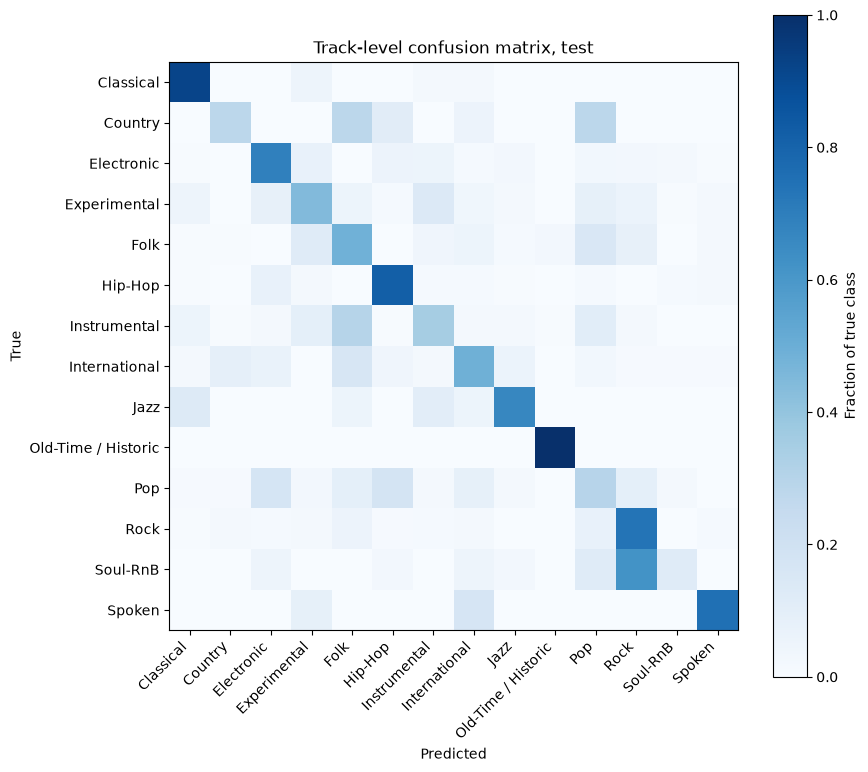

In [3]:
cm = confusion_matrix(track_true, track_pred, normalize='true')

plt.figure(figsize=(9, 8))
plt.imshow(cm, vmin=0, vmax=1, cmap='Blues')
plt.colorbar(label='Fraction of true class')
plt.xticks(range(len(test.classes)), test.classes, rotation=45, ha='right')
plt.yticks(range(len(test.classes)), test.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Track-level confusion matrix, test')
plt.tight_layout()
plt.show()

Фінальні цифри: track accuracy **59.4%**, macro-F1 **0.534**, top-3 accuracy **83.8%** (випадкове вгадування на 14 класах - 7.1%).

Проти validation (62.7% / 0.548 / 0.844) просадка ~3 пункти - нормальний generalization gap: validation ми багато разів використовували для вибору чекпоінтів і моделі, тож він трохи "оптимістичний", а test бачимо вперше.

По класах картина та сама, що й на validation: впевнено розпізнаються акустично виразні жанри (Old-Time 1.00, Classical 0.92, Hip-Hop 0.82, це доволі круто), провисають розмиті категорії без власного звучання (Soul-RnB 0.12, Country 0.28, Pop 0.29) - confusion matrix показує, що їхні треки розтікаються по сусідніх популярних жанрах, а не плутаються хаотично.

Для апки робочі цифри такі: у 6 треків з 10 перший жанр вгаданий точно, у 8.4 з 10 правильний жанр у топ-3 показаного розподілу.

Я знов впираюсь в проблему жанрів: деякі жанри не показують особливостей у тональному сенсі, наприклад Pop. Якщо бути чесним, цей жанр є більше маркетинговим ходом, аніж жанром музики, який чимось виділяється в тембровому звучанні. Тому такі класи важко розрізняти - по метриках видно, що деякі мають дуже високу точність, а деякі ні.